In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt

# 1. Le decimos a Python que busque en la carpeta vecina
sys.path.append('../codigos')

# 2. Importamos el motor matemático que acabas de crear
from solvers import ftcs_1d

In [2]:
# 1. Parámetros físicos y numéricos
D = 1.0      
rho = 1.0    
nx = 400     
dx = 0.2     
dt = 0.01    
nt = 3000    

# 2. Condición inicial (El tejido)
u_0 = np.zeros(nx)
u_0[0:10] = 1.0

# 3. ¡Ejecutamos el motor 1D!
# La función nos devuelve 3 cosas: la matriz final, los tiempos y las posiciones
u_final, tiempos, posiciones = ftcs_1d(D, rho, nx, dx, dt, nt, u_0)

print("¡Simulación completada con éxito!")

¡Simulación completada con éxito!


Velocidad Analítica Teórica: 2.0000
Velocidad Computacional Simulada: 1.9118


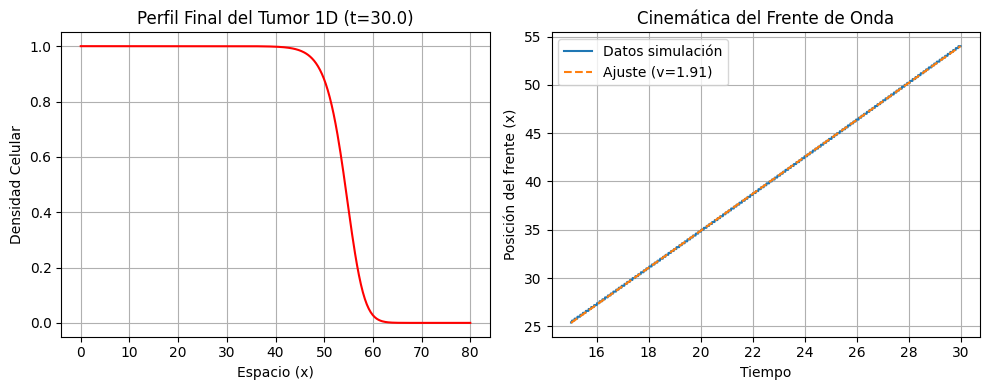

In [3]:
# 1. Análisis de la velocidad
coeficientes = np.polyfit(tiempos, posiciones, 1)
v_computacional = coeficientes[0]
v_analitica = 2 * np.sqrt(D * rho)

print(f"Velocidad Analítica Teórica: {v_analitica:.4f}")
print(f"Velocidad Computacional Simulada: {v_computacional:.4f}")

# 2. Gráficos
plt.figure(figsize=(10, 4))

# Perfil del Tumor
plt.subplot(1, 2, 1)
plt.plot(np.linspace(0, nx*dx, nx), u_final, color='red')
plt.title(f'Perfil Final del Tumor 1D (t={nt*dt})')
plt.xlabel('Espacio (x)')
plt.ylabel('Densidad Celular')
plt.grid(True)

# Cinemática del Frente
plt.subplot(1, 2, 2)
plt.plot(tiempos, posiciones, label='Datos simulación')
plt.plot(tiempos, np.polyval(coeficientes, tiempos), '--', label=f'Ajuste (v={v_computacional:.2f})')
plt.title('Cinemática del Frente de Onda')
plt.xlabel('Tiempo')
plt.ylabel('Posición del frente (x)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()